In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/Users/aryan/Documents/telco-churn-mlops/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# TotalCharges often loads as object/string with blank entries — check it
df['TotalCharges'].dtype

dtype('O')

In [7]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:6]}")

customerID: 7043 unique -> ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC']
gender: 2 unique -> ['Female' 'Male']
Partner: 2 unique -> ['Yes' 'No']
Dependents: 2 unique -> ['No' 'Yes']
PhoneService: 2 unique -> ['No' 'Yes']
MultipleLines: 3 unique -> ['No phone service' 'No' 'Yes']
InternetService: 3 unique -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique -> ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique -> ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique -> ['No' 'Yes' 'No internet service']
TechSupport: 3 unique -> ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique -> ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique -> ['No' 'Yes' 'No internet service']
Contract: 3 unique -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique -> ['Yes' 'No']
PaymentMethod: 4 unique -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: 6531 unique -> ['2

In [8]:
# Cell 8 - find the culprit rows
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
# Cell 9 - fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()  # should print 0
df['TotalCharges'].dtype  # should print float64

dtype('float64')

In [10]:
# Cell 10 - drop irrelevant ID column
df = df.drop(columns=['customerID'])

In [11]:
# Cell 11 - binary encoding for 2-category columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [12]:
# Cell 12 - one-hot encode the multi-category columns
multiclass_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=multiclass_cols)
df_encoded.shape

(7043, 41)

In [13]:
# Cell 13 - correlation with churn
plt.figure(figsize=(10, 12))
corr_with_churn = df_encoded.corr()['Churn'].sort_values(ascending=False)
corr_with_churn

Churn                                      1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
MonthlyCharges                             0.193356
PaperlessBilling                           0.191825
SeniorCitizen                              0.150889
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService                               0.011942
gender                                    -0.008612
MultipleLines_No phone service            -0.011942
MultipleLine

<Figure size 1000x1200 with 0 Axes>

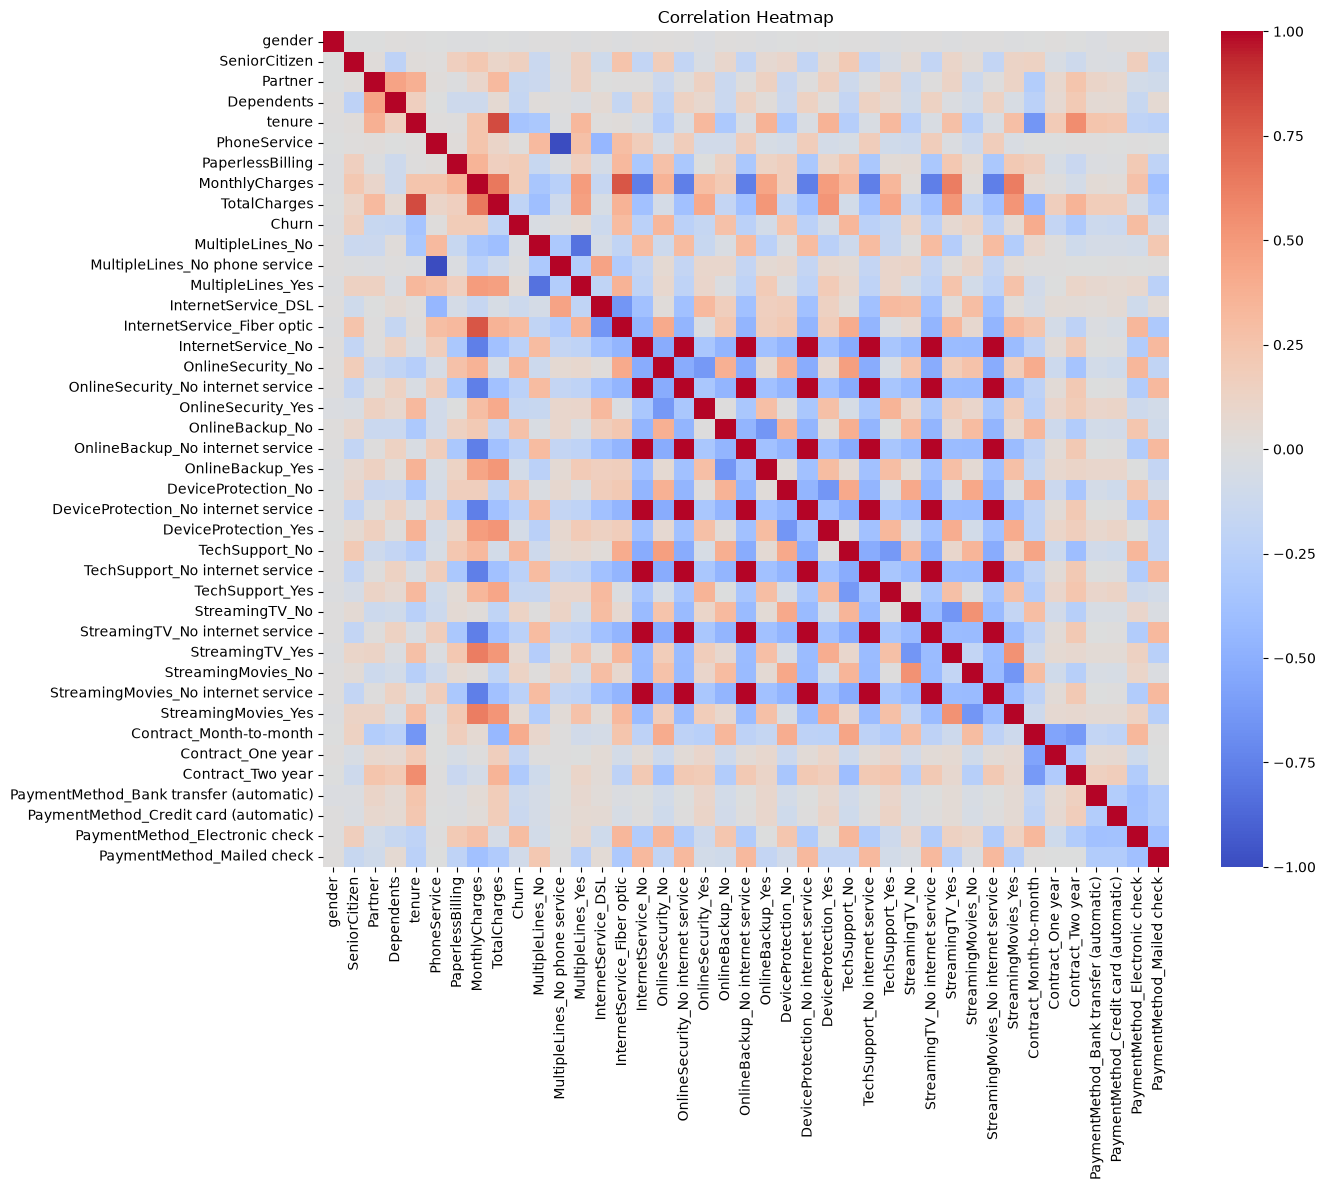

In [14]:
# Cell 14 - heatmap (visual version of the same thing)
plt.figure(figsize=(14, 12))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
# Cell 15 - VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_encoded.drop(columns=['Churn']).astype(float)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)

/Users/aryan/Documents/telco-churn-mlops/venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
20,OnlineBackup_Yes,inf
30,StreamingMovies_No,inf
23,DeviceProtection_Yes,inf
24,TechSupport_No,inf
25,TechSupport_No internet service,inf
26,TechSupport_Yes,inf
27,StreamingTV_No,inf
28,StreamingTV_No internet service,inf
29,StreamingTV_Yes,inf
31,StreamingMovies_No internet service,inf


In [16]:
# Cell 12b - re-encode dropping the first category per group
df_encoded = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)
df_encoded.shape

(7043, 31)

In [17]:
# Cell 15b - VIF check, corrected
X_vif = df_encoded.drop(columns=['Churn']).astype(float)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)

/Users/aryan/Documents/telco-churn-mlops/venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
15,OnlineBackup_No internet service,inf
12,InternetService_No,inf
19,TechSupport_No internet service,inf
17,DeviceProtection_No internet service,inf
23,StreamingMovies_No internet service,inf
13,OnlineSecurity_No internet service,inf
21,StreamingTV_No internet service,inf
5,PhoneService,1770.644580
7,MonthlyCharges,865.062147
11,InternetService_Fiber optic,148.263380


In [18]:
# Cell 16 - check class balance (business-critical metric decision)
df_encoded['Churn'].value_counts()
df_encoded['Churn'].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [19]:
# Cell 17 - save processed data for reuse
df_encoded.to_csv('/Users/aryan/Documents/telco-churn-mlops/data/processed/telco_churn_encoded.csv', index=False)
print(df_encoded.shape)

(7043, 31)


In [20]:
# Cell 18 - test modularized pipeline matches notebook logic
import sys, os
sys.path.append('..')

print("cwd:", os.getcwd())

from src.data.load_data import load_data
from src.data.preprocess import preprocess_data
from src.features.build_features import build_features

df_raw = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_clean = preprocess_data(df_raw)
df_final = build_features(df_clean)

print(df_final.shape)
assert df_final.shape == df_encoded.shape, "Mismatch! Modularized pipeline differs from notebook."
print("Match confirmed.")

cwd: /Users/aryan/Documents/telco-churn-mlops/notebooks
(7043, 31)
Match confirmed.


In [21]:
# Cell 19 - test the validator on clean raw data (should pass)
from src.validation.validate_data import validate_telco_data

df_raw_test = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
result = validate_telco_data(df_raw_test)
print("Validation passed:", result)

Validation passed: True


In [22]:
# Cell 20 - test the validator catches bad data
df_bad = df_raw_test.copy()
df_bad.loc[0, 'gender'] = 'Unknown'  # inject invalid category
df_bad.loc[1, 'tenure'] = -5         # inject invalid numeric value

try:
    validate_telco_data(df_bad)
except ValueError as e:
    print("Validation correctly caught bad data:\n")
    print(e)

Validation correctly caught bad data:

Data validation failed:
Column 'gender' has unexpected values: {'Unknown'}
tenure contains negative values


In [23]:
# Cell 21 - test baseline training with MLflow tracking
import sys
sys.path.append('..')
from src.models.train import train_model

model = train_model(df_final)

2026/07/31 00:17:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.7502
Precision: 0.5207
Recall: 0.7406
F1 Score: 0.6115

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [24]:
# Cell 22 - Optuna hyperparameter tuning
from src.models.train import tune_model

best_params = tune_model(df_final, n_trials=30)

[I 2026-07-31 00:17:16,360] A new study created in memory with name: no-name-e6db68dc-2057-4689-9dc6-ec2cf78cadb8
[I 2026-07-31 00:17:16,736] Trial 0 finished with value: 0.7620320855614974 and parameters: {'n_estimators': 543, 'max_depth': 4, 'learning_rate': 0.01727925380464687, 'subsample': 0.7387508826472858, 'colsample_bytree': 0.8275818765115035}. Best is trial 0 with value: 0.7620320855614974.
[I 2026-07-31 00:17:17,247] Trial 1 finished with value: 0.6818181818181818 and parameters: {'n_estimators': 499, 'max_depth': 7, 'learning_rate': 0.06024909891345465, 'subsample': 0.6278591038957019, 'colsample_bytree': 0.6796231142358454}. Best is trial 0 with value: 0.7620320855614974.
[I 2026-07-31 00:17:18,330] Trial 2 finished with value: 0.6417112299465241 and parameters: {'n_estimators': 721, 'max_depth': 10, 'learning_rate': 0.04657570091639987, 'subsample': 0.7808913541344366, 'colsample_bytree': 0.8272688201486569}. Best is trial 0 with value: 0.7620320855614974.
[I 2026-07-31 0

Best recall: 0.7807
Best params: {'n_estimators': 313, 'max_depth': 5, 'learning_rate': 0.010165842770028277, 'subsample': 0.8393524083955952, 'colsample_bytree': 0.7415518994257162}


In [25]:
# Cell 23b - test a few thresholds to see recall/precision tradeoff
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score
from xgboost import XGBClassifier

X = df_final.drop(columns=["Churn"])
y = df_final["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

final_params = {**best_params, "random_state": 42}
model = XGBClassifier(**final_params, eval_metric="logloss")
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15]:
    y_pred = (y_proba >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)
    print(f"threshold={t}: recall={r:.4f}, precision={p:.4f}")

threshold=0.5: recall=0.5241, precision=0.6712
threshold=0.4: recall=0.6364, precision=0.5935
threshold=0.35: recall=0.7112, precision=0.5624
threshold=0.3: recall=0.7807, precision=0.5338
threshold=0.25: recall=0.8128, precision=0.5041
threshold=0.2: recall=0.8610, precision=0.4660
threshold=0.15: recall=0.9171, precision=0.4309


In [26]:
# Cell 24 - train and log the final model at threshold 0.2
final_params = {**best_params, "random_state": 42}
final_model = train_model(df_final, params=final_params, threshold=0.2, experiment_name="telco-churn")

2026/07/31 00:21:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.7012
Precision: 0.4660
Recall: 0.8610
F1 Score: 0.6047

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.47      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409

